In [360]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [528]:
data = pd.read_csv("evo2_cds_delta_scores.csv")

transcript = [t.split(":")[0] for t in data.reference_transcript]

data['transcript'] = transcript

n_genes = len(data.reference_transcript.unique())

data.head()

,reference_transcript,haplotype,evo2_delta_score,transcript
0,ENST00000003084:REF,"ENST00000003084:1408G>A,2562T>G",0.001809,ENST00000003084
1,ENST00000003084:REF,"ENST00000003084:1408G>A,2562T>G,4389G>A",0.001816,ENST00000003084
2,ENST00000003084:REF,ENST00000003084:1408G>A,0.002322,ENST00000003084
3,ENST00000003084:REF,"ENST00000003084:1408G>A,2562T>G,3870A>G,4389G>A",0.001297,ENST00000003084
4,ENST00000003084:REF,"ENST00000003084:1408G>A,3870A>G,4389G>A",0.001891,ENST00000003084


### Calculate epistatic coefficient

In [529]:
hd = np.array([h.count(">") for h in data.haplotype])

data_2 = data[(hd <= 2)]

genes = data_2.reference_transcript.unique()

muts = data_g.haplotype

epi_coeffs = []
expected_double_mutant_effects = []
observed_double_mut_effects = []

for g in genes:
    data_g = data_2[data_2.reference_transcript == g]
    muts = data_g.haplotype
    for mut in muts:
        if mut.count(">") == 2:
            observed_double_mut_effect = data_g[np.array([m == mut for m in muts])].evo2_delta_score.iloc[0]
            try:
                mut1, mut2 = mut.split(",")
                single_mut_pos = np.array([(h == mut1) or (h == mut2) for h in muts])
                if single_mut_pos.sum() == 2:
                    expected_double_mutant_effect = data_g.evo2_delta_score[single_mut_pos].sum() 
                    print(expected_double_mutant_effect)
                    e = expected_double_mutant_effect - observed_double_mut_effect

                    expected_double_mutant_effects.append(expected_double_mutant_effect)
                    observed_double_mut_effects.append(observed_double_mut_effect)        
                    epi_coeffs.append(e)        
                else: pass
            except: pass

### Clinvar

In [413]:
import requests

def is_clinvar_variant_with_significance(ensembl_transcript, cdna_mutation):
    """
    Check if a given cDNA mutation in an Ensembl transcript is a ClinVar variant,
    and return its clinical significance if available.

    Args:
        ensembl_transcript (str): Ensembl transcript ID (e.g., "ENST00000261275")
        cdna_mutation (str): cDNA mutation in HGVS-like format (e.g., "303A>G")

    Returns:
        tuple:
            - bool: True if variant is in ClinVar, False otherwise
            - str or None: HGVS expression used for lookup
            - list or None: List of clinical significance values (e.g., ["Pathogenic"])
    """
    # Step 1: Convert Ensembl transcript to RefSeq transcript
    ensembl_server = "https://rest.ensembl.org"
    ext = f"/xrefs/id/{ensembl_transcript}?external_db=RefSeq_mRNA"
    headers = {"Content-Type": "application/json"}

    ensembl_response = requests.get(ensembl_server + ext, headers=headers)
    if not ensembl_response.ok or not ensembl_response.json():
        return False, None, None

    refseq_id = ensembl_response.json()[0]['display_id']

    # Step 2: Construct HGVS expression
    hgvs_expr = f"{refseq_id}:c.{cdna_mutation}"

    # Step 3: Search ClinVar for the HGVS expression
    esearch_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"
    esearch_params = {
        "db": "clinvar",
        "term": hgvs_expr,
        "retmode": "json"
    }
    search_response = requests.get(esearch_url, params=esearch_params)
    result = search_response.json()

    if int(result["esearchresult"]["count"]) == 0:
        return False, hgvs_expr, None

    # Step 4: Fetch clinical significance from ClinVar summary
    uid = result["esearchresult"]["idlist"][0]
    esummary_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi"
    esummary_params = {
        "db": "clinvar",
        "id": uid,
        "retmode": "json"
    }
    summary_response = requests.get(esummary_url, params=esummary_params)
    summary_data = summary_response.json()
    
#     return summary_data
    
    try:
        clinical_significance = summary_data["result"][uid]["germline_classification"]["description"]
        return True, hgvs_expr, [clinical_significance]
    except KeyError:
        return True, hgvs_expr, None

In [414]:
is_clinvar_variant_with_significance("ENST00000003084", "1408G>A")

(True, 'NM_000492.4:c.1408G>A', ['Benign/Likely benign'])

In [397]:
data_1_muts = data[[h.count(">") == 1 for h in data.haplotype]]

In [398]:
data_1_muts['mutation'] = [h.split(":")[1] for h in data_1_muts.haplotype]

<ipython-input-398-56080bb735cb>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_1_muts['mutation'] = [h.split(":")[1] for h in data_1_muts.haplotype]


In [417]:
hits = []

for i in tqdm(range(len(data_1_muts))):
    transcript = data_1_muts.iloc[i].transcript
    mutation = data_1_muts.iloc[i].mutation
    exists, hgvs, significance = is_clinvar_variant_with_significance(transcript, mutation)
    hits.append([exists, hgvs, significance])

 16%|█▌        | 2934/18607 [43:11<3:50:43,  1.13it/s]


KeyError: 'esearchresult'

In [419]:
presence = [h[0] for h in hits]
var = [h[1] for h in hits]

sig = [None if h[2] == None else h[2][0] for h in hits]
sig = [[None, None] if s == None else ['Benign' in s, 'Pathogenic' in s] for s in sig]
sig = np.array(sig)

In [536]:
VEP_benign = np.array(data_1_muts.evo2_delta_score)[np.where(sig[:, 0])]
VEP_patho = np.array(data_1_muts.evo2_delta_score)[np.where(sig[:, 1])]

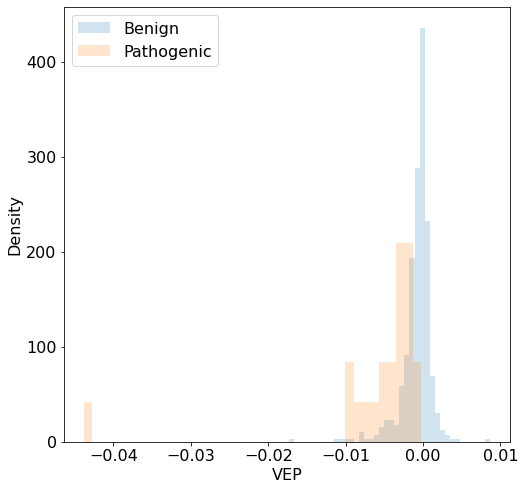

In [553]:
plt.rcParams.update({'font.size': 16})
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Nimbus Sans"]
plt.figure(figsize=(8, 8)) 
plt.hist(VEP_benign, bins=40, 
         density=True, alpha=.2, label='Benign')
plt.hist(VEP_patho, bins=40, 
         density=True, alpha=.2, label='Pathogenic')
plt.xlabel("VEP")
plt.ylabel("Density")
plt.legend()
plt.show()

In [550]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, average_precision_score, auc

# Combine scores and labels
scores = list(VEP_benign) + list(VEP_patho)
labels = [1] * len(VEP_benign) + [0] * len(VEP_patho)

# Compute AUROC
aucroc = roc_auc_score(labels, scores)
print(f"AUROC: {aucroc:.3f}")

auprc = average_precision_score(labels, scores)
print(f"AUPRC: {auprc:.3f}")

AUROC: 0.889
AUPRC: 0.995


In [552]:
precision, recall, _ = precision_recall_curve(labels, scores)
auprc = auc(recall, precision)
print(f"AUPRC: {auprc:.3f}")

AUPRC: 0.995


### VEP distribtion by mutants

In [489]:
def check_and_find_extra(mut1, mut2):
    mut1 = mut1.split(",")
    mut2 = mut2.split(",")    
    set1 = set(mut1)
    set2 = set(mut2)
    if set1.issubset(set2) and len(set2) == len(set1) + 1:
        extra_element = set2 - set1
        return extra_element.pop()  # return the one extra element
    else:
        return None  # conditions not met

mut1 = '1408G>A,2562T>G'
mut2 = '1408G>A,2562T>G,4389G>A'

In [490]:
genes = data.reference_transcript.unique()

In [491]:
VEPs_by_gene = {}

for g in tqdm(genes):
    data_g = data[data.reference_transcript == g]
    f = np.array(data_g.evo2_delta_score)
    
    muts = [h.split(":")[1] for h in data_g.haplotype]
    checks = np.array([[check_and_find_extra(mut1, mut2) for mut1 in muts] for mut2 in muts])
    variants = list(set(checks[checks != None]))

    VEPs = {}

    for v in variants:
        mut_pos, ref_pos = np.where(checks == v)
        try:
            effects = np.array(f[mut_pos]) - np.array(f[ref_pos])
            VEPs[v] = effects
        except:
            pass
    VEPs_by_gene[g] = VEPs

100%|██████████| 555/555 [11:26<00:00,  1.24s/it]  


In [495]:
VEP_filtered = {}

for g in genes:
    for v in VEPs_by_gene[g].keys():
        if len(VEPs_by_gene[g][v]) > 40:
            key = g.split(":")[0] + '_' + v
            VEP_filtered[key] = VEPs_by_gene[g][v]

In [502]:
variants = list(VEP_filtered.keys())

In [506]:
plots_per_page = cols * rows
figsize = (8.3, 11.7)  

# Create a PdfPages object
with PdfPages("figs/" + 'hist.pdf') as pdf:
    for page_start in range(0, len(variants), plots_per_page):
        # Create a new figure for each page
        fig, axes = plt.subplots(rows, cols, figsize=figsize)
        axes = axes.flatten()

        # Iterate over the data for the current page
        for i, mut in enumerate(list(variants)[page_start:page_start + plots_per_page]):
            ax = axes[i]
            plot_data = VEP_filtered[mut]
            ax.hist(plot_data, bins=30, color='blue', alpha=0.7)
            ax.set_title(mut, fontsize=8)
            ax.tick_params(axis='both', which='major', labelsize=6)
            ax.set_xlim(-0.01, 0.002)

        # Hide any unused subplots
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])
            
        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)